In [109]:
import mujoco as mj
import mujoco.viewer
from pathlib import Path
import time
import numpy as np
import matplotlib.pyplot as plt

In [110]:
REPO_NAME = "preERP"

XML_RELATIVE_PATH = Path("mechanical/mujoco_assets/MyPalletizer260/MyPalletizer260.xml")

def find_repo_root(start: Path, name: str = REPO_NAME) -> Path:
    """Sube desde `start` hasta el ancestro llamado `name`.

    `start` incluido: si ya estas parado en el repo, no sube nada. Si el
    nombre no aparece, cae a la busqueda por marcador (pyproject.toml), que
    es lo que hace que esto siga funcionando si renombras la carpeta.
    """
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if candidate.name.lower() == name.lower():
            return candidate
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError(
        f"No se encontro la carpeta '{name}' ni un pyproject.toml subiendo "
        f"desde {start}. Corre el notebook dentro del repo, o fija repo_root a mano."
    )


repo_root = find_repo_root(Path.cwd())
model_path = (repo_root / XML_RELATIVE_PATH).resolve()

if not model_path.is_file():
    raise FileNotFoundError(
        f"Repo root OK ({repo_root}), pero no existe {XML_RELATIVE_PATH} adentro."
        f"Buscado en: {model_path}"
    )

print(f"repo root:  {repo_root}")
print(f"Cargando modelo MuJoCo desde: {model_path}")

model = mj.MjModel.from_xml_path(str(model_path))
data = mj.MjData(model)
mj.mj_resetDataKeyframe(model, data, model.key("home").id)

print(f"Modelo cargado OK -> bodies: {model.nbody}, joints: {model.njnt}, "
      f"geoms: {model.ngeom}, actuadores: {model.nu}")
for j in range(model.njnt):
    print("  joint", j, mj.mj_id2name(model, mj.mjtObj.mjOBJ_JOINT, j))

print("qpos0 =", model.qpos0,"\n qpos =", data.qpos)

repo root:  C:\Users\nicoa\Desktop\Universidad\ERP\preERP
Cargando modelo MuJoCo desde: C:\Users\nicoa\Desktop\Universidad\ERP\preERP\mechanical\mujoco_assets\MyPalletizer260\MyPalletizer260.xml
Modelo cargado OK -> bodies: 6, joints: 4, geoms: 26, actuadores: 3
  joint 0 rot
  joint 1 link1
  joint 2 link2
  joint 3 act
qpos0 = [ 1.57   -3.1415  1.57    1.57  ] 
 qpos = [0.     0.     0.     1.5693]


In [111]:
# Masa del modelo. Hay DOS totales y los dos son legitimos, asi que conviene
# ver los dos: `base_link` no tiene junta, asi que MuJoCo lo suelda al mundo
# (body_weldid = 0) y su masa no la carga ninguna junta ni la mueve la gravedad.
# Para dimensionar servos o leer pares, el numero que importa es la masa MOVIL.
G = 9.81
movil = np.array([model.body_weldid[b] != 0 for b in range(model.nbody)])

print(f"{'body':<12}{'masa [kg]':>11}   estado")
for b in range(model.nbody):
    if model.body_mass[b] == 0.0:
        continue  # el body `world` pesa 0 por definicion
    name = mj.mj_id2name(model, mj.mjtObj.mjOBJ_BODY, b)
    print(f"{name:<12}{model.body_mass[b]:>11.4f}   "
          + ("movil" if movil[b] else "soldado al mundo"))

m_total = model.body_mass.sum()
m_movil = model.body_mass[movil].sum()
print(f"\nmasa total = {m_total:7.4f} kg  ({m_total * G:6.2f} N)  <- todo el ensamble")
print(f"masa movil = {m_movil:7.4f} kg  ({m_movil * G:6.2f} N)  <- lo que cargan las juntas")
print(f"base fija  = {m_total - m_movil:7.4f} kg  ({(m_total - m_movil) * G:6.2f} N)  <- soldada al mundo")

body          masa [kg]   estado
base_link        0.3063   soldado al mundo
rot              0.1826   movil
link1            0.1834   movil
link2            0.2471   movil
act              0.0495   movil

masa total =  0.9689 kg  (  9.51 N)  <- todo el ensamble
masa movil =  0.6626 kg  (  6.50 N)  <- lo que cargan las juntas
base fija  =  0.3063 kg  (  3.01 N)  <- soldada al mundo


In [112]:
SLOWMO_ON = False      # <-- interruptor: False = tiempo real, True = camara lenta
SLOWMO_FACTOR = 10.0   # cuanto mas lento cuando SLOWMO_ON = True
JOINT_DAMPING = 0.05   # N*m*s/rad; 0.0 = caida libre eterna (ver nota arriba)
GRAVITY_ON = True      # False = el brazo se queda como esta, para inspeccionarlo
FPS = 60.0             # frames dibujados por segundo, independiente del slowmo

AXES_VISIBLE = True    # triadas XYZ de los sites al arrancar el visor.
                       # Equivalente sin codigo: tecla 2 adentro del visor.
AXES_GROUP = 2         # los geoms de axis_xyz.xml viven todos en el grupo 2

VMAX_DEG_S = 120.0     # spec del brazo. Unico dato de hardware que tenemos.
RATE_LIMIT_ON = True   # False = escalon crudo, para ver por que hace falta
VMAX = np.radians(VMAX_DEG_S)

slowmo = SLOWMO_FACTOR if SLOWMO_ON else 1.0

model.dof_damping[:] = JOINT_DAMPING
model.opt.gravity[:] = (0, 0, -9.81) if GRAVITY_ON else (0, 0, 0)

model.opt.integrator = mj.mjtIntegrator.mjINT_IMPLICITFAST

estado = f"ON (x{SLOWMO_FACTOR:g})" if SLOWMO_ON else "OFF (tiempo real)"
print(f"camara lenta: {estado}")
print(f"integrador:   {mj.mjtIntegrator(model.opt.integrator).name}")
print(f"limite de consigna: {'ON' if RATE_LIMIT_ON else 'OFF'} ({VMAX_DEG_S:.0f} deg/s)")
print(f"timestep={model.opt.timestep * 1e3:.0f} ms, dibujo a {FPS:.0f} fps "
      f"-> {1 / FPS / (model.opt.timestep * slowmo):.1f} pasos de fisica por frame")

n_axes = int((model.geom_group == AXES_GROUP).sum())
print(f"triadas XYZ:  {'ON' if AXES_VISIBLE else 'OFF'} al arrancar "
      f"({n_axes} geoms en el grupo {AXES_GROUP}, {n_axes // 7} sites) "
      f"-> tecla {AXES_GROUP} en el visor")

camara lenta: OFF (tiempo real)
integrador:   mjINT_IMPLICITFAST
limite de consigna: ON (120 deg/s)
timestep=2 ms, dibujo a 60 fps -> 8.3 pasos de fisica por frame
triadas XYZ:  ON al arrancar (21 geoms en el grupo 2, 3 sites) -> tecla 2 en el visor


In [113]:
# ===========================================================================
# Registro de telemetria. Se llena adentro del bucle del visor (celda de abajo)
# y se dibuja en la celda de graficos (mas abajo).
# ===========================================================================
#
# QUE MIDE CADA SENSOR Y EN QUE MARCO. MuJoCo evalua los sensores de marco en
# el MARCO DEL SITE, no en el del mundo -- por eso existen las triadas XYZ de
# axis_xyz.xml. Del modelo (leido, no supuesto: ver la tabla que imprime abajo):
#
#   link1_acc, link2_acc   accelerometer, 3 comp, m/s^2, MARCO DEL SITE.
#                          Es FUERZA ESPECIFICA, no aceleracion coordenada: en
#                          reposo no lee 0 sino +g proyectada sobre los ejes del
#                          site, o sea |a| = 9.81. Ese modulo es el chequeo
#                          barato de que el site esta bien montado: si en
#                          reposo no da 9.81, lo que esta mal es el sensor.
#   efector_pos            framepos, 3 comp, m, MARCO DEL MUNDO (origen del
#                          site `efector` visto desde el mundo).
#
# Los tres tienen noise=0 y cutoff=0: son sensores IDEALES. El ruido que
# necesites para probar un filtro hay que inyectarlo aca; MuJoCo no lo pone.
#
# ALINEACION TEMPORAL -- lo unico delicado de todo esto. `mj_step` evalua los
# sensores ANTES de integrar, asi que al volver de `mj_step` conviven DOS
# tiempos en el mismo `data`: `qpos`/`qvel` ya son de t+dt, pero `sensordata`
# (y `xpos`, y `site_xpos`) siguen siendo de t. Guardar las dos mitades como si
# fueran del mismo instante mete un sesgo de un paso entero en toda la serie, y
# eso no se ve en el grafico: aparece despues como sesgo del filtro. Medido en
# este modelo: tras un `mj_step` desde `home`, sensordata[efector_pos] es
# EXACTAMENTE el site_xpos previo (diferencia 0.0) y difiere del posterior en
# 2.8e-4 m. Por eso `SimLog.step()` hace el paso el mismo: la alineacion vive
# en un solo lugar, y grabando con el no hay forma de olvidarla en el bucle.

LOG_STRIDE = 1     # 1 = graba cada paso de fisica (500 Hz con dt=2 ms).
                   # 5 = 100 Hz. Subilo solo si la memoria molesta: submuestrear
                   # un acelerometro es exactamente aliasear su vibracion.


def sensor_layout(model):
    """{nombre: slice} dentro de data.sensordata, leido del modelo.

    Se lee del modelo en vez de escribir los indices a mano porque el orden y
    el ancho de `sensordata` los decide el XML: agregar un sensor arriba de la
    lista corre a todos los de abajo, y unos indices fijos seguirian dando
    numeros -- solo que del sensor equivocado.
    """
    layout = {}
    for i in range(model.nsensor):
        name = mj.mj_id2name(model, mj.mjtObj.mjOBJ_SENSOR, i)
        adr = int(model.sensor_adr[i])
        layout[name] = slice(adr, adr + int(model.sensor_dim[i]))
    return layout


class SimLog:
    """Telemetria a paso de fisica, con los sensores alineados en tiempo.

    Uso dentro del bucle::

        log = SimLog(model)
        ...
        log.step(model, data)      # EN VEZ DE mujoco.mj_step(model, data)

    Columnas (todas con `len(log)` filas y el mismo eje de tiempo):

        t     [s]      tiempo de sim del estado guardado
        qpos  [rad]    angulo de cada junta (qpos = 0 es la pose de ensamble)
        qvel  [rad/s]  velocidad de cada junta
        ctrl  [rad]    consigna efectivamente escrita en los servos ese paso
        sens  [varias] data.sensordata crudo; usar log.sensor("link1_acc")

    Arranca con `capacity` filas y duplica cuando se llena, asi una sesion
    larga de visor no obliga a adivinar la duracion de antemano.
    """

    def __init__(self, model, stride=1, capacity=8192):
        self.stride = max(1, int(stride))
        self.dt = float(model.opt.timestep)
        self.layout = sensor_layout(model)
        self.joint_names = [mj.mj_id2name(model, mj.mjtObj.mjOBJ_JOINT, j)
                            for j in range(model.njnt)]
        self.qadr = model.jnt_qposadr.copy()
        # actuador -> junta que mueve, para poder comparar consigna contra medida
        self.act_names = [mj.mj_id2name(model, mj.mjtObj.mjOBJ_ACTUATOR, a)
                          for a in range(model.nu)]
        self.act_joint = [int(model.actuator_trnid[a, 0]) for a in range(model.nu)]
        self._n = 0    # filas completas
        self._k = 0    # pasos vistos (para el stride)
        self._t = np.empty(capacity)
        self._qpos = np.empty((capacity, model.nq))
        self._qvel = np.empty((capacity, model.nv))
        self._ctrl = np.empty((capacity, model.nu))
        self._sens = np.empty((capacity, model.nsensordata))

    def _grow(self):
        for name in ("_t", "_qpos", "_qvel", "_ctrl", "_sens"):
            arr = getattr(self, name)
            setattr(self, name, np.concatenate([arr, np.empty_like(arr)], axis=0))

    def step(self, model, data):
        """Avanza la fisica un paso y graba el estado y los sensores DE ESE paso.

        El estado (qpos/qvel/ctrl) se copia ANTES de integrar y los sensores
        DESPUES, porque `mj_step` los calculo a partir de ese mismo estado
        previo. Las dos mitades quedan etiquetadas con el mismo `t`, que es lo
        que las hace comparables. `_n` se incrementa recien al final: si algo
        revienta a mitad de camino no queda una fila a medio llenar.
        """
        take = (self._k % self.stride) == 0
        self._k += 1
        if take:
            if self._n == len(self._t):
                self._grow()
            i = self._n
            self._t[i] = data.time
            self._qpos[i] = data.qpos
            self._qvel[i] = data.qvel
            self._ctrl[i] = data.ctrl
        mj.mj_step(model, data)
        if take:
            self._sens[i] = data.sensordata
            self._n += 1

    def __len__(self):
        return self._n

    @property
    def t(self):
        return self._t[:self._n]

    @property
    def qpos(self):
        return self._qpos[:self._n]

    @property
    def qvel(self):
        return self._qvel[:self._n]

    @property
    def ctrl(self):
        return self._ctrl[:self._n]

    def sensor(self, name):
        """Columnas de un sensor por nombre, (N, dim). Unidades y marco: ver arriba."""
        if name not in self.layout:
            raise KeyError(f"'{name}' no es un sensor de este modelo. "
                           f"Hay: {list(self.layout)}")
        return self._sens[:self._n, self.layout[name]]

    def joint(self, name):
        """Angulo de una junta por nombre, (N,) en rad."""
        return self._qpos[:self._n, self.qadr[self.joint_names.index(name)]]

    def save(self, path):
        """Vuelca el registro a un .npz, para reanalizar sin volver a abrir el visor."""
        np.savez_compressed(path, t=self.t, qpos=self.qpos, qvel=self.qvel,
                            ctrl=self.ctrl, sens=self._sens[:self._n],
                            joint_names=np.array(self.joint_names),
                            sensor_names=np.array(list(self.layout)))
        return path




# Inventario real de sensores del modelo cargado.
print(f"{'sensor':<14}{'tipo':<24}{'site':<12}{'dim':>4}{'adr':>5}   noise  cutoff")
for i in range(model.nsensor):
    print(f"{mj.mj_id2name(model, mj.mjtObj.mjOBJ_SENSOR, i):<14}"
          f"{mj.mjtSensor(model.sensor_type[i]).name:<24}"
          f"{mj.mj_id2name(model, model.sensor_objtype[i], model.sensor_objid[i]):<12}"
          f"{model.sensor_dim[i]:>4}{model.sensor_adr[i]:>5}"
          f"{model.sensor_noise[i]:>8.3g}{model.sensor_cutoff[i]:>8.3g}")

_ncol = model.nq + model.nv + model.nu + model.nsensordata + 1
_rate = 1.0 / (model.opt.timestep * LOG_STRIDE)
print(f"\nregistro: stride={LOG_STRIDE} -> {_rate:.0f} Hz, {_ncol} columnas por fila "
      f"(~{_ncol * 8 * _rate * 60 / 1e6:.1f} MB por minuto de simulacion)")

sensor        tipo                    site         dim  adr   noise  cutoff
link1_acc     mjSENS_ACCELEROMETER    link1_site     3    0       0       0
link2_acc     mjSENS_ACCELEROMETER    link2_site     3    3       0       0
efector_pos   mjSENS_FRAMEPOS         efector        3    6       0       0

registro: stride=1 -> 500 Hz, 21 columnas por fila (~5.0 MB por minuto de simulacion)


In [ ]:
FRAME_DT = 1.0 / FPS       # FPS se fija arriba, en la celda de perillas
MAX_STEPS_PER_FRAME = 200  # tope anti-espiral: si la fisica no llega, se atrasa
                           # en vez de trabarse tratando de alcanzar el reloj.

# Hacer resetDatakeyframe al keyframe de home para poner el robot en la posicion inicial
mj.mj_resetDataKeyframe(model, data, model.key("home").id)
data.ctrl[:] = data.qpos[:model.nu]   # arrancar pidiendo la pose actual
cmd = data.ctrl.copy()
target = data.ctrl.copy()
last_written = data.ctrl.copy()
max_step = VMAX * model.opt.timestep

# Registro NUEVO por corrida. Si se reusara el de la corrida anterior, el
# tiempo volveria a cero a mitad del array (el reset de arriba reinicia
# data.time) y el eje x del grafico dejaria de ser monotono.
log = SimLog(model, stride=LOG_STRIDE)

with mujoco.viewer.launch_passive(model, data) as viewer:
    # Prender/apagar las triadas XYZ. `opt` lo lee el hilo de render, asxi que
    # todo toque va adentro de viewer.lock(); sin el, el cambio compite con el
    # dibujo. Esto es SOLO un filtro de dibujo: apagarlas no toca la fisica ni
    # los sensores, los sites siguen midiendo igual. La tecla 2 hace lo mismo.
    with viewer.lock():
        viewer.opt.geomgroup[AXES_GROUP] = int(AXES_VISIBLE)

    wall_start = time.perf_counter()
    next_frame = wall_start
    while viewer.is_running():
        # Avanzar la fisica hasta el tiempo de sim que le toca al proximo frame.
        # A 2 ms de paso y 60 fps son ~8 pasos por frame, no 1.
        target_sim_time = (next_frame - wall_start) / slowmo
        steps = 0
        while data.time < target_sim_time and steps < MAX_STEPS_PER_FRAME:
            # --- tu codigo va aca: escribi el objetivo en `target[:]` ---
            # ------------------------------------------------------------
            if not np.array_equal(data.ctrl, last_written):
                target[:] = data.ctrl        # moviste un slider
            if RATE_LIMIT_ON:
                cmd += np.clip(target - cmd, -max_step, max_step)
            else:
                cmd[:] = target
            data.ctrl[:] = cmd
            last_written[:] = cmd

            # Reemplaza a mujoco.mj_step: da el paso Y graba. El muestreo va
            # ACA, en el bucle de fisica, no afuera junto al viewer.sync():
            # muestrear por frame (60 Hz) aliasea los acelerometros y se pierde
            # justo lo que hace falta ver.
            log.step(model, data)

            steps += 1

        viewer.sync()  # UN sync por frame. Uno por paso son 500 Hz contra una
                       # pantalla de 60 Hz: trabajo tirado, y el sleep de 2 ms
                       # que hacia falta para sostenerlo no existe en Windows
                       # (un sleep(2ms) mide 2.86 ms de mediana aca).

        # Deadline del proximo frame. `target_sim_time` se sigue midiendo contra
        # `wall_start` (tiempo absoluto), asi que un frame que se pasa de largo
        # no deja la sim corriendo adelantada para siempre.
        next_frame += FRAME_DT
        now = time.perf_counter()
        if now < next_frame:
            time.sleep(next_frame - now)
        else:
            next_frame = now  # nos pasamos: re-anclar, no acumular deuda

print(f"Visor cerrado tras {data.time:.2f} s de simulacion. "
      f"Grabadas {len(log)} muestras a {1 / (log.dt * log.stride):.0f} Hz "
      f"-> corre la celda de graficos.")

In [ ]:
print(f"masa total del modelo: {model.body_mass.sum():.4f} kg\n")
for b in range(model.nbody):
    if model.body_mass[b] == 0.0:
        continue
    name = mj.mj_id2name(model, mj.mjtObj.mjOBJ_BODY, b)
    print(f"  {name:<12}{model.body_mass[b]:.4f} kg")

masa total del modelo: 0.9689 kg

  base_link   0.3063 kg
  rot         0.1826 kg
  link1       0.1834 kg
  link2       0.2471 kg
  act         0.0495 kg


In [ ]:
sensors_data = sensor_layout(model)
for i in sensors_data.keys():
    print(f"Sensor name: {i}, {sensors_data[i]}")

Sensor name: link1_acc, slice(0, 3, None)
Sensor name: link2_acc, slice(3, 6, None)
Sensor name: efector_pos, slice(6, 9, None)


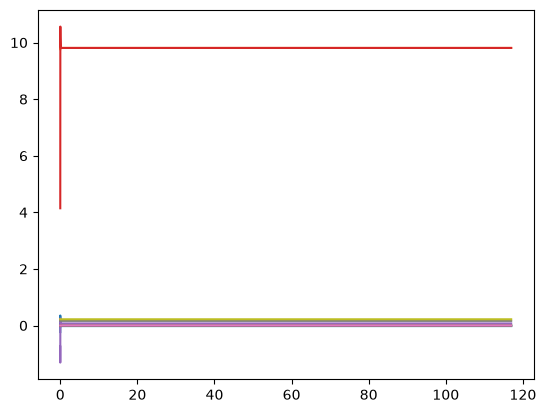

In [ ]:
for i in sensors_data.keys():
    plt.plot(log.t,log.sensor(i))